![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [1]:
# !sudo apt-get install libgomp1
# !sudo apt-get install libxft2
# !sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [3]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [4]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

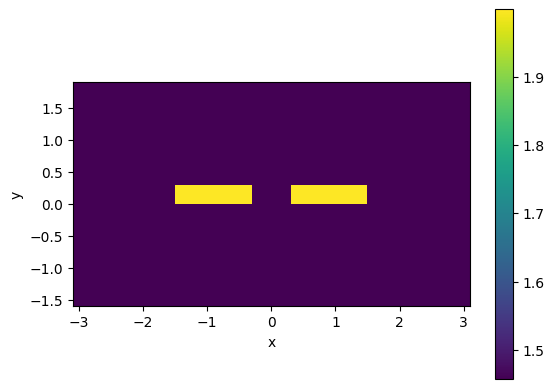

In [5]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=30 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [6]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-01 11:28:15.242 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_34835ab47ea23281.npz.
[1.61793773+9.80777918e-05j 1.61017908+9.35979812e-05j
 1.53709743+1.75770034e-04j 1.52225525+1.75486218e-04j]


In [7]:
dcoupler_cs.fraction_te

array([0.99553025, 0.99595819, 0.00824261, 0.01038074])

In [8]:
dcoupler_cs.fraction_tm

array([0.00446975, 0.00404181, 0.99175739, 0.98961926])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

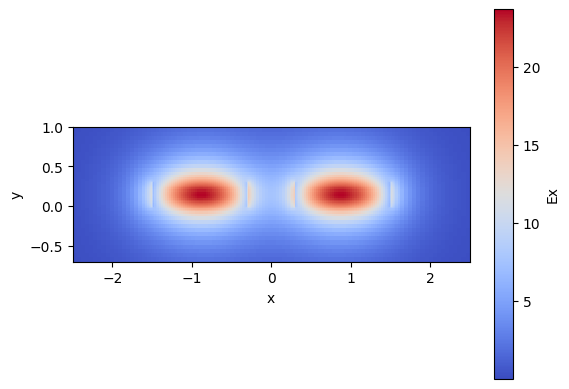

In [9]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

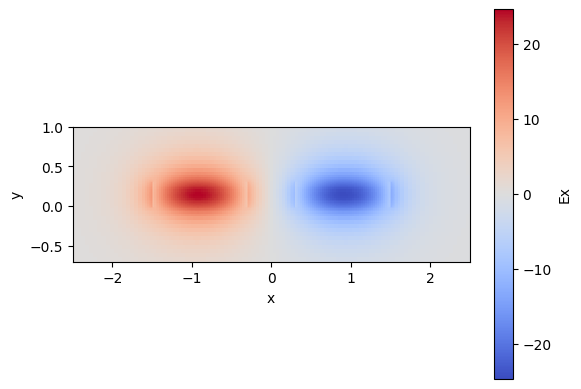

In [10]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

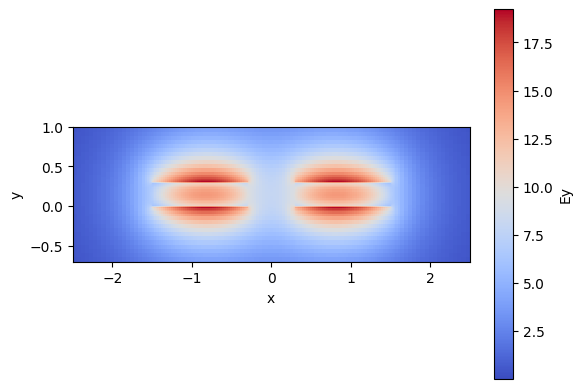

In [11]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

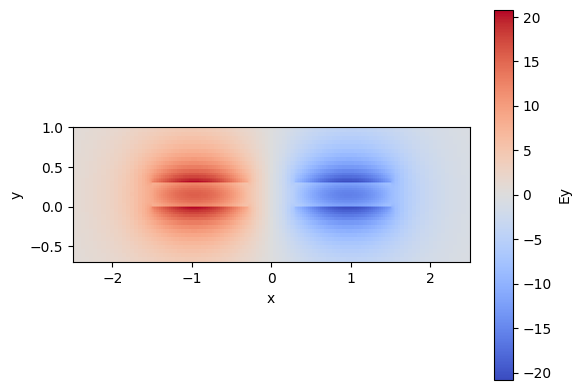

In [12]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [13]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

99.88859193722972
52.21605465376124


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [14]:
dcoupler_cs.coupling_length()

array([99.88859194, 52.21605465])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">
<img src="k.png" alt="Coupling Coefficient Equation" width="400" style="filter: invert();">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

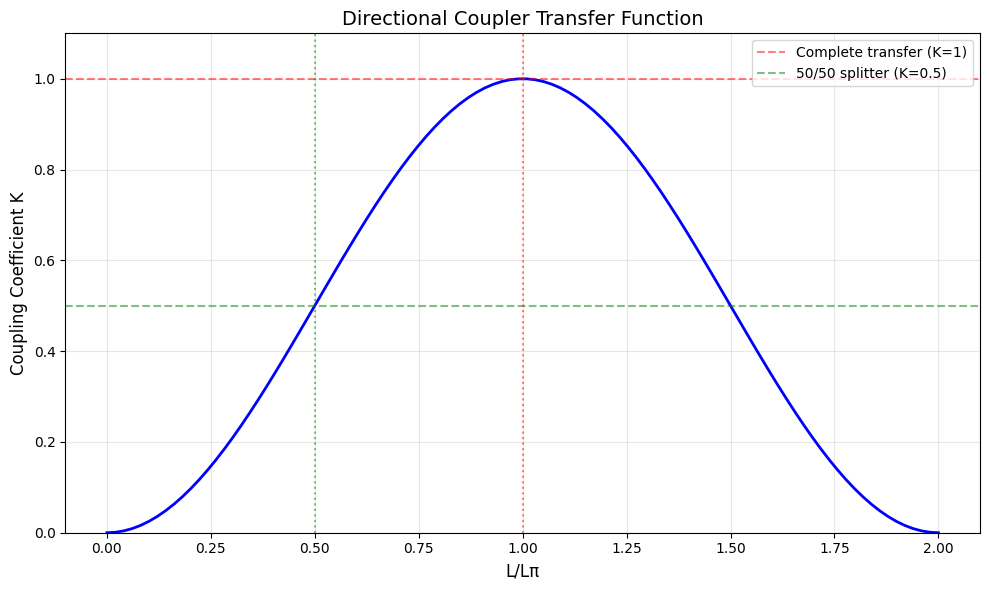

Resultados importantes:
- Transferencia completa (K=1): L = Lπ = 99.89 µm
- Splitter 50/50 (K=0.5): L = Lπ/2 = 49.94 µm
- Sin acoplamiento (K=0): L = 0, 2Lπ, 4Lπ...


In [15]:
# LO.2 - Plot K vs L/Lπ
import numpy as np
import matplotlib.pyplot as plt

# Define range of L/Lπ values
L_ratio = np.linspace(0, 2, 100)

# Calculate coupling coefficient K = sin²(πL/2Lπ)
K = np.sin(np.pi * L_ratio / 2)**2

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(L_ratio, K, 'b-', linewidth=2)
plt.xlabel('L/Lπ', fontsize=12)
plt.ylabel('Coupling Coefficient K', fontsize=12)
plt.title('Directional Coupler Transfer Function', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Complete transfer (K=1)')
plt.axhline(y=0.5, color='g', linestyle='--', alpha=0.5, label='50/50 splitter (K=0.5)')
plt.axvline(x=1.0, color='r', linestyle=':', alpha=0.5)
plt.axvline(x=0.5, color='g', linestyle=':', alpha=0.5)
plt.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

print("Resultados importantes:")
print(f"- Transferencia completa (K=1): L = Lπ = {L_pi_TE:.2f} µm")
print(f"- Splitter 50/50 (K=0.5): L = Lπ/2 = {L_pi_TE/2:.2f} µm")
print(f"- Sin acoplamiento (K=0): L = 0, 2Lπ, 4Lπ...")

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [16]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605177636  µm


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


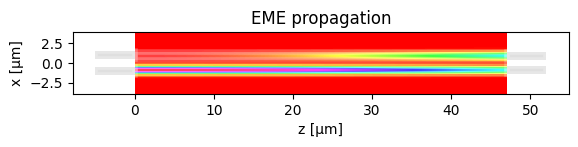

In [17]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

Simulating gap = 0.2 um


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/258 [00:00<?, ?it/s]

------- Pameters -------
MMI length 12.9071
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7802
Total OUT power: 0.7586
Excess loss [dB] =  1.2000
------------------------
Power over OUTs:  ['0.3792', '0.3794']
Ratio over OUTs ['0.4999', '0.5001']
L_pi = 25.8142 um
L_50:50 = 12.9071 um
Power OUT = [0.37919436 0.37938446]
Ratio OUT = [0.4998747 0.5001253]
Excess loss = 1.2000 dB
--------------------------------------------------
Simulating gap = 0.4 um


...

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9560
Excess loss [dB] =  0.1955
------------------------
Power over OUTs:  ['0.4778', '0.4782']
Ratio over OUTs ['0.4998', '0.5002']
L_pi = 318.8842 um
L_50:50 = 159.4421 um
Power OUT = [0.47781327 0.47818036]
Ratio OUT = [0.49980801 0.50019199]
Excess loss = 0.1955 dB
--------------------------------------------------
Simulating gap = 1.2 um


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2147
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8916
Total OUT power: 0.8818
Excess loss [dB] =  0.5464
------------------------
Power over OUTs:  ['0.4407', '0.4410']
Ratio over OUTs ['0.4998', '0.5002']
L_pi = 580.4294 um
L_50:50 = 290.2147 um
Power OUT = [0.44074861 0.44102762]
Ratio OUT = [0.49984179 0.50015821]
Excess loss = 0.5464 dB
--------------------------------------------------


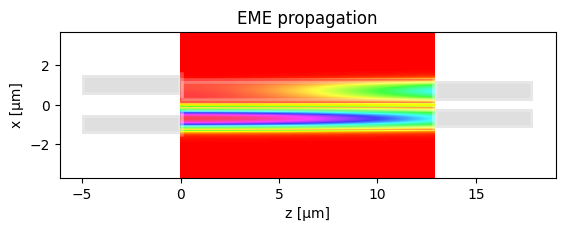

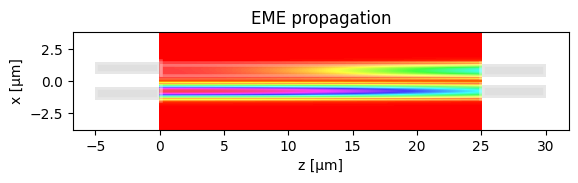

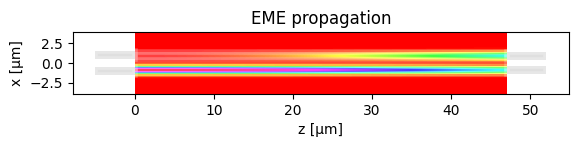

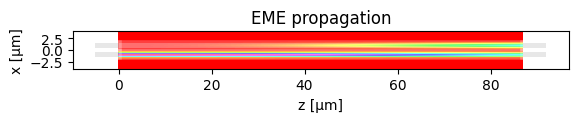

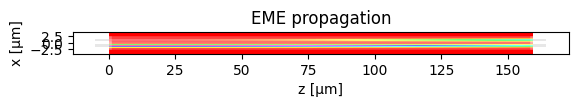

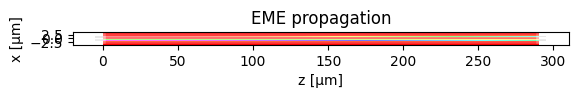

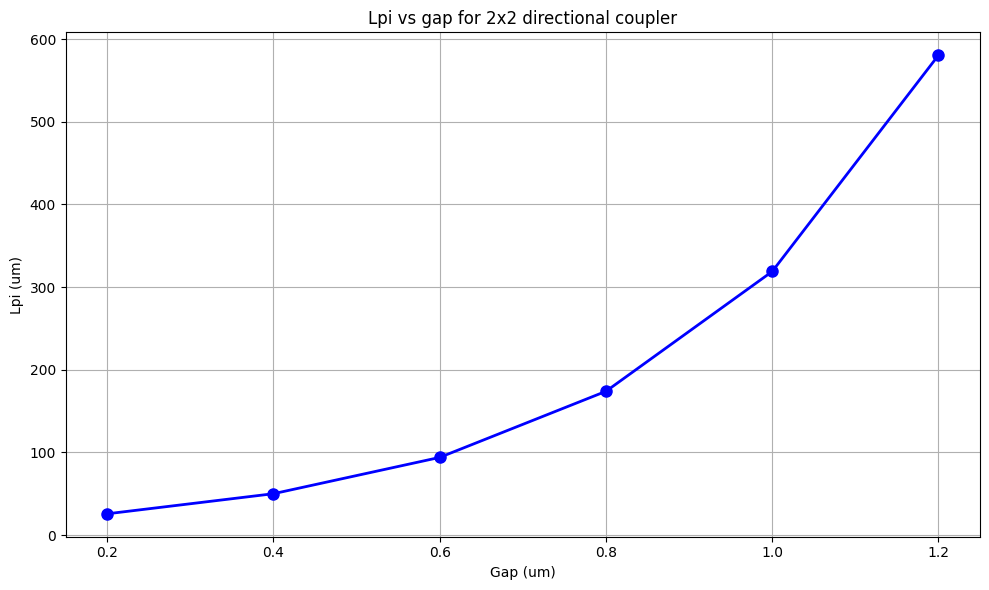

In [18]:
# LO.3 - Sweep gaps between 0.2 and 1.2 um

gaps_to_sweep = np.arange(0.2, 1.4, 0.2)

results_gap_sweep = []

for gap in gaps_to_sweep:
    print(f"Simulating gap = {gap:.1f} um")

    m_sweep = DC_EME()
    m_sweep.MMI_num_modes = 12
    m_sweep.DC_wg_gap = gap
    m_sweep.DC_wg_width = 1.2
    m_sweep.DC_N_waveguides = 2

    # Calculate modes
    m_sweep.find_all_modes()

    # Calculate L_pi
    L_pi_sweep = m_sweep.get_L_pi()
    L_5050_sweep = 0.5 * L_pi_sweep

    # Configure 2x2 50/50 coupler
    m_sweep.n_IN = 2
    m_sweep.n_OUT = 2
    m_sweep.L_MMI = L_5050_sweep

    # Propagation
    m_sweep.propagation()

    results_gap_sweep.append({
        "gap": gap,
        "L_pi": L_pi_sweep,
        "L_5050": L_5050_sweep,
        "power_OUT": m_sweep.power_OUT,
        "ratio_OUT": m_sweep.ratio_OUT,
        "excess_loss_dB": m_sweep.EL
    })

    print(f"L_pi = {L_pi_sweep:.4f} um")
    print(f"L_50:50 = {L_5050_sweep:.4f} um")
    print(f"Power OUT = {m_sweep.power_OUT}")
    print(f"Ratio OUT = {m_sweep.ratio_OUT}")
    print(f"Excess loss = {m_sweep.EL:.4f} dB")
    print("-" * 50)

# Plot L_pi vs gap
gaps = [r["gap"] for r in results_gap_sweep]
L_pis = [r["L_pi"] for r in results_gap_sweep]

plt.figure(figsize=(10, 6))
plt.plot(gaps, L_pis, "bo-", linewidth=2, markersize=8)
plt.xlabel("Gap (um)")
plt.ylabel("Lpi (um)")
plt.title("Lpi vs gap for 2x2 directional coupler")
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# LO.3 - 2x2 Directional Coupler
# Caso individual para sacar la propagación del gap que quieras estudiar

wg_width = 1.2
gap_selected = 0.6   # cámbialo luego a 0.2, 0.4, 0.6, 0.8, 1.0, 1.2

wg_N = 2

m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = gap_selected
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N

# 1) Calcular modos del directional coupler
m.find_all_modes()

# 2) Obtener L_pi y longitud 50:50
L_pi = m.get_L_pi()
L_5050 = 0.5 * L_pi

print(f"Gap = {gap_selected:.1f} um")
print(f"L_pi = {L_pi:.4f} um")
print(f"L_50:50 = L_pi/2 = {L_5050:.4f} um")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Gap = 0.6 um
L_pi = 94.0274 um
L_50:50 = L_pi/2 = 47.0137 um


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


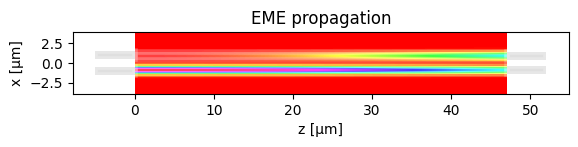

In [20]:
# Configuración 2x2 y propagación para el gap elegido arriba

m.n_IN = 2
m.n_OUT = 2

# Para un 3 dB coupler / 50:50
m.L_MMI = L_5050

# Ejecutar propagación y mostrar resultados
m.propagation()

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



HINT. Calculate manually the L_pi you may need to achieve K=0.01
Then you can sweep the gap and calculate the L_pi until reaching 
the desired value.

Condición para guías desacopladas:
K objetivo = 0.01
L = 10.0 mm
Lpi mínimo requerido = 156.82 mm
Delta neff máximo permitido = 4.942e-06

--- Deep waveguide ---
2026-05-01 11:31:38.195 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_c735717a8742a223.npz.
gap = 0.20 um | Lpi = 0.0180 mm | K = 1.0000
2026-05-01 11:31:38.227 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f0903b36a6669153.npz.
gap = 0.40 um | Lpi = 0.0328 mm | K = 1.0000
2026-05-01 11:31:38.234 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_40b89b65a6f22400.npz.
gap = 0.60 um | Lpi = 0.0595 mm | K = 1.0000
2026-05-01 11:31:38.238 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_16be99bd3e78a9eb.npz.
gap = 0.80 um | Lpi = 0.1047 mm | K = 1.0000
2026-05-01 11:31:38.243 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_81cd52b7728ca66a.npz

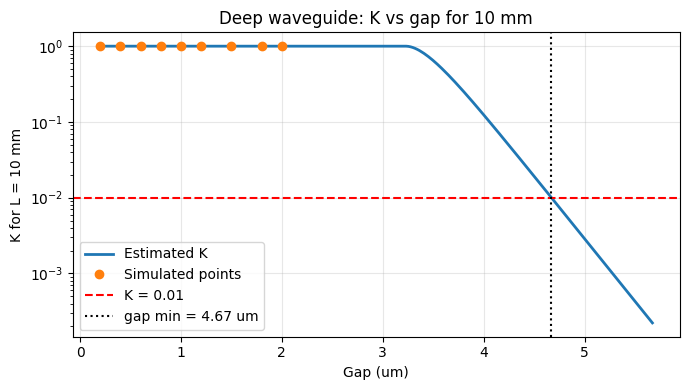


Resultado Deep:
gap mínimo estimado = 4.67 um
Lpi requerido = 156.82 mm
K objetivo = 0.01

--- Shallow waveguide ---
2026-05-01 11:31:38.565 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b562e744298eb15d.npz.
gap = 0.20 um | Lpi = 0.0185 mm | K = 1.0000
2026-05-01 11:31:38.584 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_7035fcd667db234e.npz.
gap = 0.40 um | Lpi = 0.0271 mm | K = 1.0000
2026-05-01 11:31:38.587 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d91696d09038bbb2.npz.
gap = 0.60 um | Lpi = 0.0397 mm | K = 1.0000
2026-05-01 11:31:38.592 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_abf251362ccac02d.npz.
gap = 0.80 um | Lpi = 0.0580 mm | K = 1.0000
2026-05-01 11:31:38.598 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f737b1eb28a10412.npz.
gap = 1.00 um | Lpi = 0.0843 mm | K = 1.00

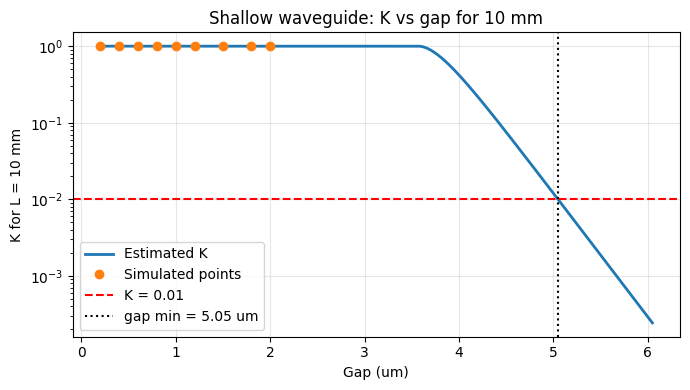


Resultado Shallow:
gap mínimo estimado = 5.05 um
Lpi requerido = 156.82 mm
K objetivo = 0.01

Resumen final LO.4:
Deep waveguide: gap mínimo estimado = 4.67 um
Shallow waveguide: gap mínimo estimado = 5.05 um


In [21]:
# LO.4 - Parallel uncoupled waveguides - TE0 mode

try:
    nm
except NameError:
    nm = 1e-3

# Parámetros del enunciado
lambda_lo4 = 1.55      # um
wg_width_lo4 = 1.0     # um
core_h_lo4 = 300 * nm  # 300 nm = 0.3 um

L_parallel = 10_000    # um = 10 mm
K_target = 0.01

slab_deep = 0 * nm
slab_shallow = 150 * nm

# Cálculo manual del Lpi necesario para tener K = 0.01
# K = sin^2((pi/2)*(L/Lpi))
L_over_Lpi_limit = (2 / np.pi) * np.arcsin(np.sqrt(K_target))
Lpi_required = L_parallel / L_over_Lpi_limit
dneff_required = lambda_lo4 / (2 * Lpi_required)

print("Condición para guías desacopladas:")
print(f"K objetivo = {K_target}")
print(f"L = {L_parallel/1000:.1f} mm")
print(f"Lpi mínimo requerido = {Lpi_required/1000:.2f} mm")
print(f"Delta neff máximo permitido = {dneff_required:.3e}")


def get_te0_lpi(gap_um, slab_thickness_um, grid_resolution=12):
    """
    Calcula Lpi usando los dos modos TE principales del acoplador.
    """
    dc = gt.modes.WaveguideCoupler(
        core_width=(wg_width_lo4, wg_width_lo4),
        slab_thickness=slab_thickness_um,
        core_thickness=core_h_lo4,
        gap=gap_um,
        core_material="sin",
        clad_material="sio2",
        wavelength=lambda_lo4,
        num_modes=4,
        cache_path=".cache/",
        precision="double",
        max_grid_scaling=1.5,
        grid_resolution=grid_resolution,
    )

    neff = np.array(dc.n_eff).real
    frac_te = np.array(dc.fraction_te)

    # Elegimos los dos modos más TE
    te_idx = np.where(frac_te > 0.5)[0]

    if len(te_idx) < 2:
        te_idx = np.argsort(frac_te)[-2:]

    # Ordenamos por neff para coger los dos supermodos TE principales
    te_idx = te_idx[np.argsort(neff[te_idx])[::-1]]
    i0, i1 = te_idx[:2]

    delta_neff = abs(neff[i0] - neff[i1])
    Lpi = lambda_lo4 / (2 * delta_neff)

    return Lpi, delta_neff, neff[i0], neff[i1]


def K_from_Lpi_conservative(Lpi):
    """
    K para L = 10 mm.
    Usamos una estimación conservadora para evitar mínimos accidentales
    por periodicidad cuando las guías todavía están muy acopladas.
    """
    phase = (np.pi / 2) * (L_parallel / Lpi)

    if phase >= np.pi / 2:
        return 1.0
    else:
        return np.sin(phase) ** 2


def analyze_waveguide_type(slab_thickness_um, label):
    """
    Barrido + ajuste exponencial para estimar el gap mínimo.
    El acoplo evanescente decrece aproximadamente de forma exponencial con el gap.
    """
    print(f"\n--- {label} waveguide ---")

    # Barrido moderado: evita ir a gaps demasiado grandes donde el solver puede volverse inestable
    gap_sim = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0])

    results = []

    for gap in gap_sim:
        try:
            Lpi, dneff, neff0, neff1 = get_te0_lpi(gap, slab_thickness_um)

            K_value = K_from_Lpi_conservative(Lpi)

            results.append({
                "gap": gap,
                "Lpi": Lpi,
                "dneff": dneff,
                "K": K_value,
                "neff0": neff0,
                "neff1": neff1,
            })

            print(
                f"gap = {gap:.2f} um | "
                f"Lpi = {Lpi/1000:.4f} mm | "
                f"K = {K_value:.4f}"
            )

        except Exception as e:
            print(f"gap = {gap:.2f} um failed: {e}")

    gaps = np.array([r["gap"] for r in results])
    dneffs = np.array([r["dneff"] for r in results])
    Lpis = np.array([r["Lpi"] for r in results])
    Ks = np.array([r["K"] for r in results])

    # Ajuste exponencial: delta_neff = A * exp(B * gap)
    # Filtramos puntos no físicos donde Lpi no aumenta al aumentar el gap
    valid = np.isfinite(dneffs) & (dneffs > 0) & np.isfinite(Lpis)

    cummax_Lpi = np.maximum.accumulate(Lpis)
    monotonic = Lpis >= np.r_[-np.inf, cummax_Lpi[:-1]]

    fit_mask = valid & monotonic

    fit_gaps = gaps[fit_mask]
    fit_dneffs = dneffs[fit_mask]

    # Si hay muchos puntos, quitamos el primero para ajustar mejor la zona evanescente
    if len(fit_gaps) > 5:
        fit_gaps = fit_gaps[1:]
        fit_dneffs = fit_dneffs[1:]

    B, logA = np.polyfit(fit_gaps, np.log(fit_dneffs), 1)
    A = np.exp(logA)

    # Gap mínimo estimado para cumplir delta_neff < delta_neff_required
    gap_min = (np.log(dneff_required) - logA) / B

    # Curva extrapolada para pintar K vs gap
    gap_curve = np.linspace(0.2, max(gap_min + 1.0, 3.0), 250)
    dneff_curve = A * np.exp(B * gap_curve)
    Lpi_curve = lambda_lo4 / (2 * dneff_curve)
    K_curve = np.array([K_from_Lpi_conservative(Lpi) for Lpi in Lpi_curve])

    # Gráfica para el PPT
    plt.figure(figsize=(7, 4))
    plt.plot(gap_curve, K_curve, "-", linewidth=2, label="Estimated K")
    plt.plot(gaps, Ks, "o", label="Simulated points")
    plt.axhline(K_target, linestyle="--", color="red", label="K = 0.01")
    plt.axvline(gap_min, linestyle=":", color="black", label=f"gap min = {gap_min:.2f} um")

    plt.xlabel("Gap (um)")
    plt.ylabel("K for L = 10 mm")
    plt.title(f"{label} waveguide: K vs gap for 10 mm")
    plt.grid(True, alpha=0.3)
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nResultado {label}:")
    print(f"gap mínimo estimado = {gap_min:.2f} um")
    print(f"Lpi requerido = {Lpi_required/1000:.2f} mm")
    print(f"K objetivo = {K_target}")

    return {
        "label": label,
        "gap_min": gap_min,
        "A": A,
        "B": B,
        "results": results,
    }


deep_result = analyze_waveguide_type(slab_deep, "Deep")
shallow_result = analyze_waveguide_type(slab_shallow, "Shallow")

print("\nResumen final LO.4:")
print(f"Deep waveguide: gap mínimo estimado = {deep_result['gap_min']:.2f} um")
print(f"Shallow waveguide: gap mínimo estimado = {shallow_result['gap_min']:.2f} um")

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [22]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-05-01 11:31:38.884 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [23]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

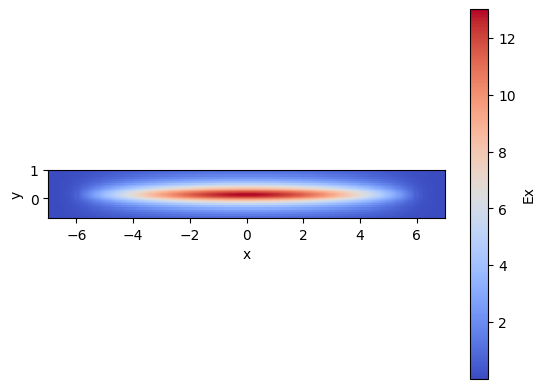

In [24]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

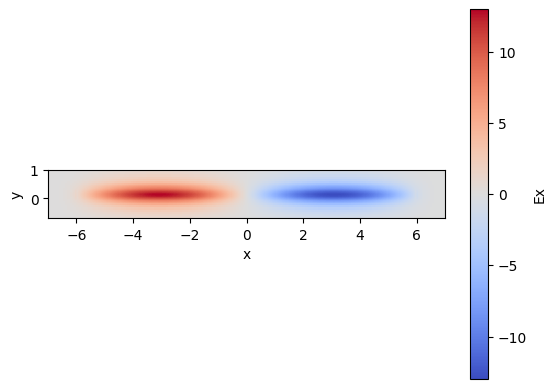

In [25]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

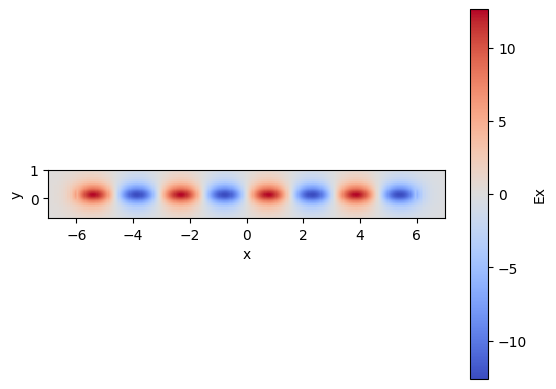

In [26]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [27]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794418495


In [28]:
# LO.5 - Summary for the report (AÑADIDO)

neff = mmi_body_waveguide.n_eff
fraction_te = mmi_body_waveguide.fraction_te

print("MMI body width =", mmi_body_w, "um")
print("Wavelength =", lambda_c, "um")
print("Deep-etched waveguide, thickness = 300 nm")
print()

print("First calculated modes:")
for i in range(10):
    pol = "TE-like" if fraction_te[i] > 0.5 else "TM-like"
    print(
        f"mode {i}: "
        f"neff = {neff[i].real:.6f}, "
        f"fraction_TE = {fraction_te[i]:.4f}, "
        f"{pol}"
    )

print()
print("Lpi calculation:")
print(f"neff mode 0 = {neff[0].real:.6f}")
print(f"neff mode 1 = {neff[1].real:.6f}")
print(f"Delta neff = {d_n_eff:.6f}")
print(f"Lpi = {L_pi:.4f} um")

MMI body width = 12 um
Wavelength = 1.55 um
Deep-etched waveguide, thickness = 300 nm

First calculated modes:
mode 0: neff = 1.678660, fraction_TE = 1.0000, TE-like
mode 1: neff = 1.675127, fraction_TE = 1.0000, TE-like
mode 2: neff = 1.669228, fraction_TE = 0.9999, TE-like
mode 3: neff = 1.660945, fraction_TE = 0.9999, TE-like
mode 4: neff = 1.650253, fraction_TE = 0.9998, TE-like
mode 5: neff = 1.637121, fraction_TE = 0.9997, TE-like
mode 6: neff = 1.621513, fraction_TE = 0.9995, TE-like
mode 7: neff = 1.603391, fraction_TE = 0.9993, TE-like
mode 8: neff = 1.582715, fraction_TE = 0.9990, TE-like
mode 9: neff = 1.577421, fraction_TE = 0.0002, TM-like

Lpi calculation:
neff mode 0 = 1.678660
neff mode 1 = 1.675127
Delta neff = 0.003532
Lpi = 219.4112 um


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [29]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255869  µm


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


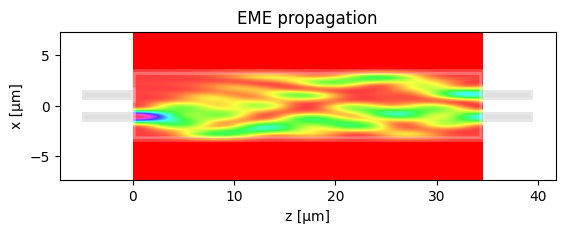

In [30]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9149
Excess loss [dB] =  0.3861
------------------------
Power over OUTs:  ['0.4631', '0.4518']
Ratio over OUTs ['0.5062', '0.4938']


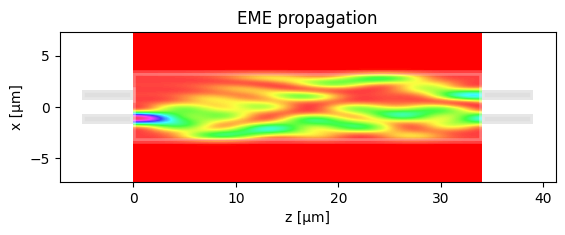

In [31]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [32]:
# Design flow for MMI

mmi_Width = 6.6


m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.7 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256687  µm


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/678 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.6000
IO wg width 1.0000
IO wg width increment 0.7000
------------------------
Total power IN coupled 0.9919
Total OUT power: 0.9824
Excess loss [dB] =  0.0773
------------------------
Power over OUTs:  ['0.5013', '0.4811']
Ratio over OUTs ['0.5103', '0.4897']


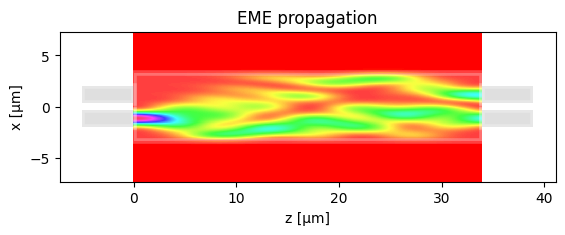

In [33]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.065
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.60 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [34]:
# LO.7 - 1x4 Multimode Interference Coupler

mmi_Width = 12.0

m = MMI_EME()
m.MMI_width = mmi_Width
m.MMI_num_modes = 30
m.wg_width_dw = 0.6

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.1393154408758  µm


/home/pablo/cifoin/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/812 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.6000
------------------------
Total power IN coupled 0.9919
Total OUT power: 0.9529
Excess loss [dB] =  0.2097
------------------------
Power over OUTs:  ['0.2347', '0.2418', '0.2418', '0.2346']
Ratio over OUTs ['0.2463', '0.2537', '0.2538', '0.2462']


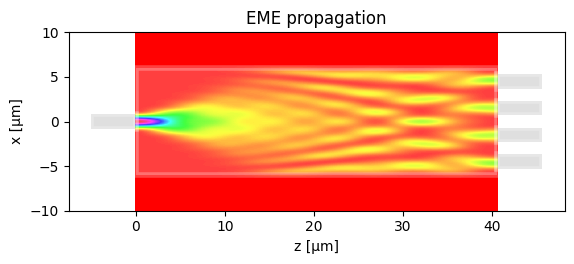

In [35]:
# Configure 1x4 MMI

m.n_IN = 1
m.n_OUT = 4

m.IN_WVG_positions = np.array([0.0])

m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8])

m.L_MMI = (3/4) * L_pi / m.n_OUT
m.dL_MMI = -0.5

m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

Deep - gap = 0.2 um
2026-05-01 11:34:02.513 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
Deep - gap = 0.4 um
2026-05-01 11:34:02.520 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_266d67620f0948f9.npz.
Deep - gap = 0.6 um
2026-05-01 11:34:02.527 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fa4c4babd472f540.npz.
Deep - gap = 0.8 um
2026-05-01 11:34:02.534 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f8167db7728a9ebb.npz.
Deep - gap = 1.0 um
2026-05-01 11:34:02.541 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b0f701e58db4a1bf.npz.
Deep - gap = 1.2 um
2026-05-01 11:34:02.548 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_de78bc7bac7ad149.npz.
Deep - gap = 1.4 um
2026-05-01 11:34:02.551 | INFO     | gplugins.tidy3d.modes:_data:266

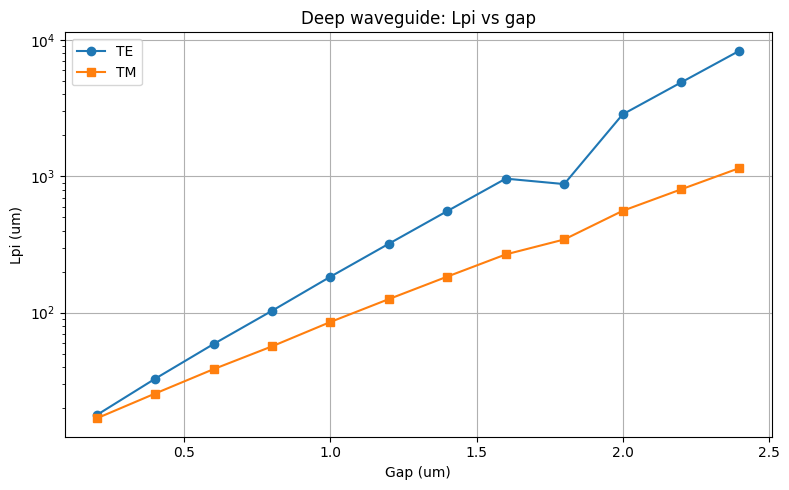

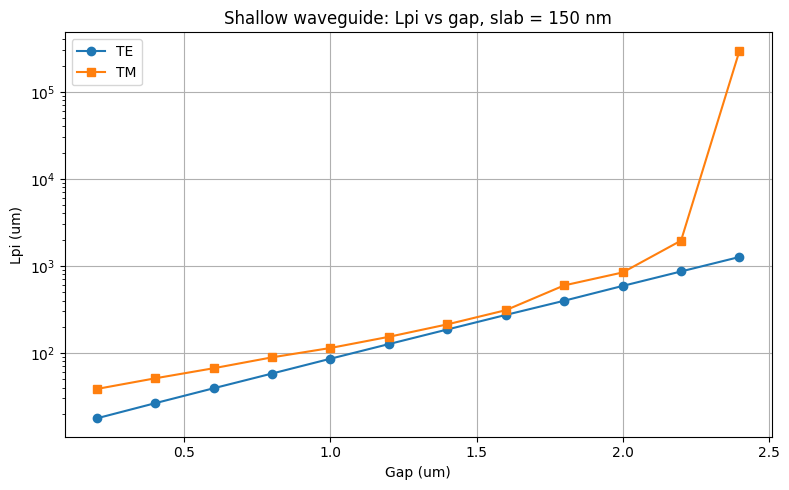


Deep waveguide results
gap = 0.2 um | Lpi_TE = 17.69 um | Lpi_TM = 16.72 um
gap = 0.4 um | Lpi_TE = 32.69 um | Lpi_TM = 25.45 um
gap = 0.6 um | Lpi_TE = 58.77 um | Lpi_TM = 38.43 um
gap = 0.8 um | Lpi_TE = 103.11 um | Lpi_TM = 56.51 um
gap = 1.0 um | Lpi_TE = 183.51 um | Lpi_TM = 85.35 um
gap = 1.2 um | Lpi_TE = 320.54 um | Lpi_TM = 125.67 um
gap = 1.4 um | Lpi_TE = 556.78 um | Lpi_TM = 183.82 um
gap = 1.6 um | Lpi_TE = 963.20 um | Lpi_TM = 267.43 um
gap = 1.8 um | Lpi_TE = 878.42 um | Lpi_TM = 344.28 um
gap = 2.0 um | Lpi_TE = 2855.03 um | Lpi_TM = 558.73 um
gap = 2.2 um | Lpi_TE = 4898.71 um | Lpi_TM = 803.36 um
gap = 2.4 um | Lpi_TE = 8380.03 um | Lpi_TM = 1151.93 um

Shallow waveguide results
gap = 0.2 um | Lpi_TE = 17.71 um | Lpi_TM = 38.52 um
gap = 0.4 um | Lpi_TE = 26.45 um | Lpi_TM = 51.07 um
gap = 0.6 um | Lpi_TE = 39.25 um | Lpi_TM = 66.68 um
gap = 0.8 um | Lpi_TE = 57.95 um | Lpi_TM = 88.93 um
gap = 1.0 um | Lpi_TE = 85.76 um | Lpi_TM = 113.95 um
gap = 1.2 um | Lpi_TE = 126

In [36]:
# E1. Directional coupler gap dependence
# Lpi vs gap for TE and TM
# Deep waveguide and shallow waveguide with slab = 150 nm

lambda_c = 1.55
wg_width = 1.0
gap_values = np.arange(0.2, 2.4 + 0.2, 0.2)

def calculate_Lpi_vs_gap(slab_thickness, label):
    Lpi_TE = []
    Lpi_TM = []

    for gap_to_simulate in gap_values:
        print(f"{label} - gap = {gap_to_simulate:.1f} um")

        dcoupler_cs = gt.modes.WaveguideCoupler(
            wavelength=lambda_c,
            core_width=(wg_width, wg_width),
            gap=gap_to_simulate,
            slab_thickness=slab_thickness,
            core_material='sin',
            clad_material='sio2',
            core_thickness=300 * nm,
            num_modes=4,
            cache_path='.cache/',
            precision='double',
            max_grid_scaling=1.5,
            grid_resolution=20
        )

        neff = np.array(dcoupler_cs.n_eff).real
        fraction_te = np.array(dcoupler_cs.fraction_te)

        # Identify TE-like modes and TM-like modes
        te_modes = np.where(fraction_te > 0.5)[0]
        tm_modes = np.where(fraction_te <= 0.5)[0]

        # Fallback if the automatic classification fails
        if len(te_modes) < 2:
            te_modes = np.array([0, 1])
        if len(tm_modes) < 2:
            tm_modes = np.array([2, 3])

        # First two TE-like modes
        te0, te1 = te_modes[0], te_modes[1]
        d_neff_TE = abs(neff[te0] - neff[te1])
        Lpi_TE.append(0.5 * lambda_c / d_neff_TE)

        # First two TM-like modes
        tm0, tm1 = tm_modes[0], tm_modes[1]
        d_neff_TM = abs(neff[tm0] - neff[tm1])
        Lpi_TM.append(0.5 * lambda_c / d_neff_TM)

    return np.array(Lpi_TE), np.array(Lpi_TM)


# Deep waveguide
Lpi_TE_deep, Lpi_TM_deep = calculate_Lpi_vs_gap(
    slab_thickness=0 * nm,
    label="Deep"
)

# Shallow waveguide
Lpi_TE_shallow, Lpi_TM_shallow = calculate_Lpi_vs_gap(
    slab_thickness=150 * nm,
    label="Shallow"
)


# Plot deep waveguide
plt.figure(figsize=(8, 5))
plt.plot(gap_values, Lpi_TE_deep, "o-", label="TE")
plt.plot(gap_values, Lpi_TM_deep, "s-", label="TM")
plt.xlabel("Gap (um)")
plt.ylabel("Lpi (um)")
plt.title("Deep waveguide: Lpi vs gap")
plt.grid(True)
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()


# Plot shallow waveguide
plt.figure(figsize=(8, 5))
plt.plot(gap_values, Lpi_TE_shallow, "o-", label="TE")
plt.plot(gap_values, Lpi_TM_shallow, "s-", label="TM")
plt.xlabel("Gap (um)")
plt.ylabel("Lpi (um)")
plt.title("Shallow waveguide: Lpi vs gap, slab = 150 nm")
plt.grid(True)
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()


# Print numerical results
print("\nDeep waveguide results")
for i, gap in enumerate(gap_values):
    print(f"gap = {gap:.1f} um | Lpi_TE = {Lpi_TE_deep[i]:.2f} um | Lpi_TM = {Lpi_TM_deep[i]:.2f} um")

print("\nShallow waveguide results")
for i, gap in enumerate(gap_values):
    print(f"gap = {gap:.1f} um | Lpi_TE = {Lpi_TE_shallow[i]:.2f} um | Lpi_TM = {Lpi_TM_shallow[i]:.2f} um")

### E2. Directional coupler wavelength dependence

2026-05-01 11:34:03.082 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d7fb4453216b17d7.npz.
2026-05-01 11:34:03.089 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8f04dc623f0a74d0.npz.


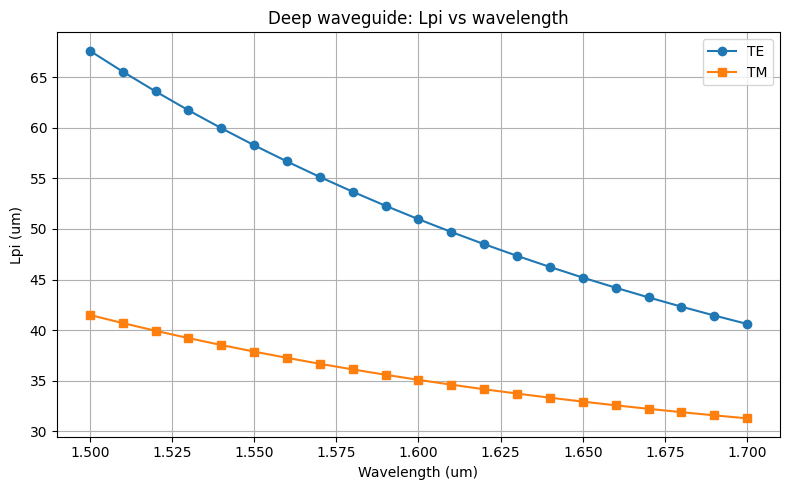

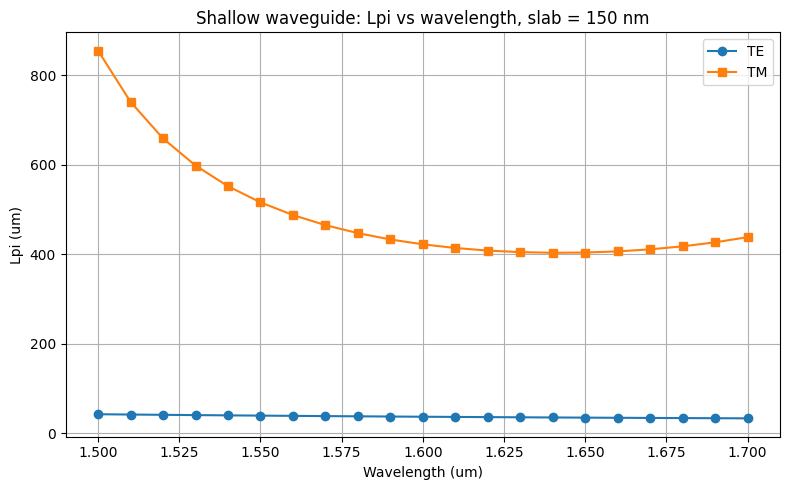

Deep waveguide results
lambda = 1.500 um | Lpi_TE = 67.60 um | Lpi_TM = 41.51 um
lambda = 1.510 um | Lpi_TE = 65.54 um | Lpi_TM = 40.71 um
lambda = 1.520 um | Lpi_TE = 63.58 um | Lpi_TM = 39.95 um
lambda = 1.530 um | Lpi_TE = 61.72 um | Lpi_TM = 39.22 um
lambda = 1.540 um | Lpi_TE = 59.95 um | Lpi_TM = 38.54 um
lambda = 1.550 um | Lpi_TE = 58.27 um | Lpi_TM = 37.89 um
lambda = 1.560 um | Lpi_TE = 56.66 um | Lpi_TM = 37.27 um
lambda = 1.570 um | Lpi_TE = 55.13 um | Lpi_TM = 36.69 um
lambda = 1.580 um | Lpi_TE = 53.68 um | Lpi_TM = 36.13 um
lambda = 1.590 um | Lpi_TE = 52.29 um | Lpi_TM = 35.60 um
lambda = 1.600 um | Lpi_TE = 50.96 um | Lpi_TM = 35.10 um
lambda = 1.610 um | Lpi_TE = 49.70 um | Lpi_TM = 34.62 um
lambda = 1.620 um | Lpi_TE = 48.49 um | Lpi_TM = 34.17 um
lambda = 1.630 um | Lpi_TE = 47.34 um | Lpi_TM = 33.74 um
lambda = 1.640 um | Lpi_TE = 46.25 um | Lpi_TM = 33.34 um
lambda = 1.650 um | Lpi_TE = 45.20 um | Lpi_TM = 32.95 um
lambda = 1.660 um | Lpi_TE = 44.20 um | Lpi_TM = 

In [37]:
# E2. Directional coupler wavelength dependence
# Lpi vs wavelength for TE and TM
# Deep and shallow waveguides

wavelength = np.linspace(1.50, 1.70, 21) # STUDENT code goes here

wg_width = 1.0
gap = 0.6


def get_Lpi_TE_TM_vs_wavelength(slab_thickness, label):

    dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(wg_width, wg_width), # Waveguide width
        gap=gap,
        slab_thickness=slab_thickness,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = np.array(dcoupler_cs.n_eff).real

    # Depending on solver output shape
    if neff.shape[0] == len(wavelength):
        neff_TE0 = neff[:, 0]
        neff_TE1 = neff[:, 1]
        neff_TM0 = neff[:, 2]
        neff_TM1 = neff[:, 3]
    else:
        neff_TE0 = neff[0, :]
        neff_TE1 = neff[1, :]
        neff_TM0 = neff[2, :]
        neff_TM1 = neff[3, :]

    L_pi_TE = 0.5 * wavelength / (neff_TE0 - neff_TE1)
    L_pi_TM = 0.5 * wavelength / (neff_TM0 - neff_TM1)

    return L_pi_TE, L_pi_TM


# Deep waveguide
L_pi_TE_deep, L_pi_TM_deep = get_Lpi_TE_TM_vs_wavelength(
    slab_thickness=0 * nm,
    label="Deep"
)

# Shallow waveguide
L_pi_TE_shallow, L_pi_TM_shallow = get_Lpi_TE_TM_vs_wavelength(
    slab_thickness=150 * nm,
    label="Shallow"
)


# Plot deep waveguide
plt.figure(figsize=(8, 5))
plt.plot(wavelength, L_pi_TE_deep, "o-", label="TE")
plt.plot(wavelength, L_pi_TM_deep, "s-", label="TM")
plt.xlabel("Wavelength (um)")
plt.ylabel("Lpi (um)")
plt.title("Deep waveguide: Lpi vs wavelength")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


# Plot shallow waveguide
plt.figure(figsize=(8, 5))
plt.plot(wavelength, L_pi_TE_shallow, "o-", label="TE")
plt.plot(wavelength, L_pi_TM_shallow, "s-", label="TM")
plt.xlabel("Wavelength (um)")
plt.ylabel("Lpi (um)")
plt.title("Shallow waveguide: Lpi vs wavelength, slab = 150 nm")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


# Print numerical results
print("Deep waveguide results")
for i, wl in enumerate(wavelength):
    print(f"lambda = {wl:.3f} um | Lpi_TE = {L_pi_TE_deep[i]:.2f} um | Lpi_TM = {L_pi_TM_deep[i]:.2f} um")

print("\nShallow waveguide results")
for i, wl in enumerate(wavelength):
    print(f"lambda = {wl:.3f} um | Lpi_TE = {L_pi_TE_shallow[i]:.2f} um | Lpi_TM = {L_pi_TM_shallow[i]:.2f} um")

### E3. MMI coupler wavelength dependence

Simulating Deep MMI...
2026-05-01 11:34:03.329 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_766d6c32e1df6a32.npz.
TE modes used: 0 1
TM modes used: 5 6
Simulating Shallow MMI...
2026-05-01 11:34:03.339 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0a9bd126ad0aa88a.npz.


TE modes used: 0 1
TM modes used: 5 6


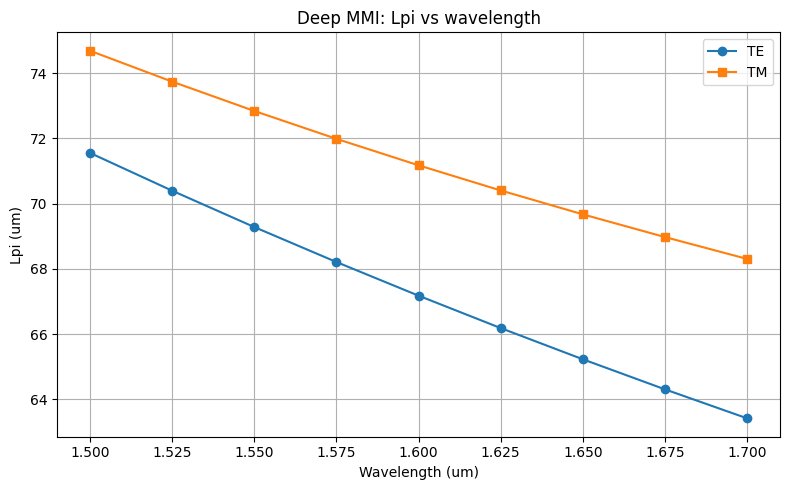

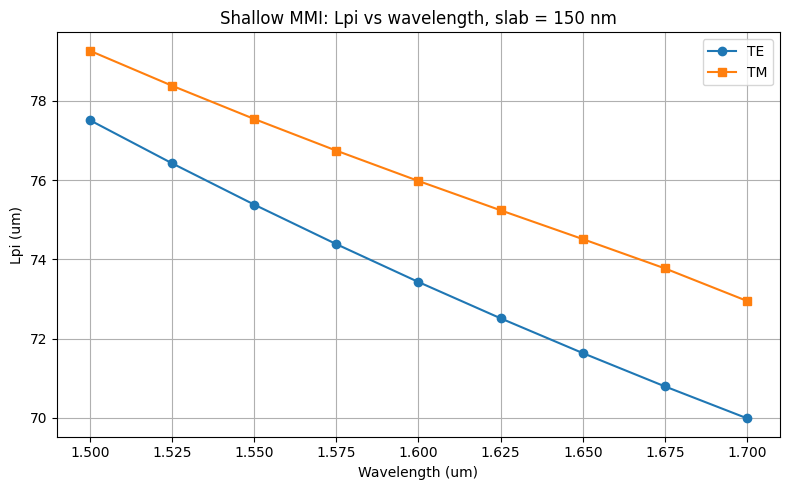


Deep MMI results
lambda = 1.500 um | Lpi_TE = 71.55 um | Lpi_TM = 74.68 um
lambda = 1.525 um | Lpi_TE = 70.39 um | Lpi_TM = 73.74 um
lambda = 1.550 um | Lpi_TE = 69.28 um | Lpi_TM = 72.84 um
lambda = 1.575 um | Lpi_TE = 68.21 um | Lpi_TM = 71.98 um
lambda = 1.600 um | Lpi_TE = 67.18 um | Lpi_TM = 71.17 um
lambda = 1.625 um | Lpi_TE = 66.18 um | Lpi_TM = 70.40 um
lambda = 1.650 um | Lpi_TE = 65.23 um | Lpi_TM = 69.67 um
lambda = 1.675 um | Lpi_TE = 64.30 um | Lpi_TM = 68.97 um
lambda = 1.700 um | Lpi_TE = 63.42 um | Lpi_TM = 68.30 um

Shallow MMI results
lambda = 1.500 um | Lpi_TE = 77.52 um | Lpi_TM = 79.27 um
lambda = 1.525 um | Lpi_TE = 76.43 um | Lpi_TM = 78.39 um
lambda = 1.550 um | Lpi_TE = 75.38 um | Lpi_TM = 77.55 um
lambda = 1.575 um | Lpi_TE = 74.39 um | Lpi_TM = 76.75 um
lambda = 1.600 um | Lpi_TE = 73.43 um | Lpi_TM = 75.98 um
lambda = 1.625 um | Lpi_TE = 72.51 um | Lpi_TM = 75.24 um
lambda = 1.650 um | Lpi_TE = 71.63 um | Lpi_TM = 74.51 um
lambda = 1.675 um | Lpi_TE = 70.7

In [38]:
# E3. MMI coupler wavelength dependence
# Lpi vs wavelength for TE and TM
# Deep and shallow MMI body

mmi_body_w = 6.6
lambda_c = np.linspace(1.50, 1.70, 9)


def calculate_MMI_Lpi_vs_wavelength(slab_thickness, label):

    print(f"Simulating {label} MMI...")

    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=300 * nm,
        slab_thickness=slab_thickness,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=20,
        max_grid_scaling=1.5,
        grid_resolution=15,
        cache_path='.cache/',
        precision='double',
    )

    neff = np.array(mmi_body_waveguide.n_eff).real
    fraction_te = np.array(mmi_body_waveguide.fraction_te)

    if neff.shape[0] != len(lambda_c):
        neff = neff.T

    te_modes = np.where(fraction_te > 0.5)[0]
    tm_modes = np.where(fraction_te <= 0.5)[0]

    if len(te_modes) < 2:
        te_modes = np.array([0, 1])

    if len(tm_modes) < 2:
        print("Warning: not enough TM modes found. Using the last two modes.")
        tm_modes = np.array([neff.shape[1] - 2, neff.shape[1] - 1])

    te0, te1 = te_modes[0], te_modes[1]
    tm0, tm1 = tm_modes[0], tm_modes[1]

    Lpi_TE = 0.5 * lambda_c / abs(neff[:, te0] - neff[:, te1])
    Lpi_TM = 0.5 * lambda_c / abs(neff[:, tm0] - neff[:, tm1])

    print("TE modes used:", te0, te1)
    print("TM modes used:", tm0, tm1)

    return Lpi_TE, Lpi_TM


Lpi_TE_deep, Lpi_TM_deep = calculate_MMI_Lpi_vs_wavelength(
    slab_thickness=0 * nm,
    label="Deep"
)

Lpi_TE_shallow, Lpi_TM_shallow = calculate_MMI_Lpi_vs_wavelength(
    slab_thickness=150 * nm,
    label="Shallow"
)


plt.figure(figsize=(8, 5))
plt.plot(lambda_c, Lpi_TE_deep, "o-", label="TE")
plt.plot(lambda_c, Lpi_TM_deep, "s-", label="TM")
plt.xlabel("Wavelength (um)")
plt.ylabel("Lpi (um)")
plt.title("Deep MMI: Lpi vs wavelength")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(lambda_c, Lpi_TE_shallow, "o-", label="TE")
plt.plot(lambda_c, Lpi_TM_shallow, "s-", label="TM")
plt.xlabel("Wavelength (um)")
plt.ylabel("Lpi (um)")
plt.title("Shallow MMI: Lpi vs wavelength, slab = 150 nm")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


print("\nDeep MMI results")
for i, wl in enumerate(lambda_c):
    print(f"lambda = {wl:.3f} um | Lpi_TE = {Lpi_TE_deep[i]:.2f} um | Lpi_TM = {Lpi_TM_deep[i]:.2f} um")

print("\nShallow MMI results")
for i, wl in enumerate(lambda_c):
    print(f"lambda = {wl:.3f} um | Lpi_TE = {Lpi_TE_shallow[i]:.2f} um | Lpi_TM = {Lpi_TM_shallow[i]:.2f} um")

### E4. MMI coupler body width dependence

Deep MMI - width = 5.0 um
2026-05-01 11:34:03.622 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ec30668a999b902b.npz.
Deep MMI - width = 5.5 um
2026-05-01 11:34:03.633 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c0fb452d8d9c70db.npz.
Deep MMI - width = 6.0 um
2026-05-01 11:34:03.638 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f21f6bf05eca73ee.npz.
Deep MMI - width = 6.5 um
2026-05-01 11:34:03.641 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1b1c56ba0da14ecb.npz.
Deep MMI - width = 7.0 um
2026-05-01 11:34:03.645 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ea749a746e45894f.npz.
Deep MMI - width = 7.5 um
2026-05-01 11:34:03.649 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a23340a2a969d1ab.npz.
Deep MMI - width = 8.0 um
2026-05-01 11:34:03.652 | INFO     | gplugins.tidy3d.modes:_data:266

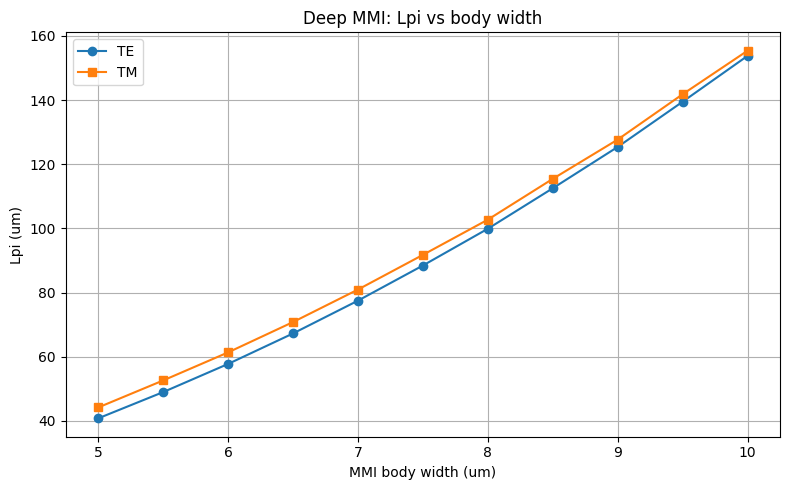

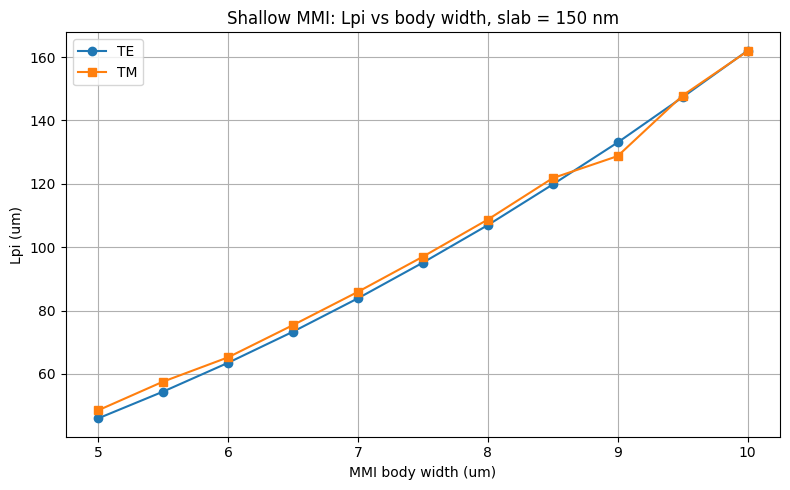


Deep MMI results
width = 5.0 um | Lpi_TE = 40.83 um | Lpi_TM = 44.22 um
width = 5.5 um | Lpi_TE = 49.01 um | Lpi_TM = 52.64 um
width = 6.0 um | Lpi_TE = 57.78 um | Lpi_TM = 61.38 um
width = 6.5 um | Lpi_TE = 67.28 um | Lpi_TM = 70.83 um
width = 7.0 um | Lpi_TE = 77.50 um | Lpi_TM = 80.95 um
width = 7.5 um | Lpi_TE = 88.45 um | Lpi_TM = 91.76 um
width = 8.0 um | Lpi_TE = 99.90 um | Lpi_TM = 102.73 um
width = 8.5 um | Lpi_TE = 112.51 um | Lpi_TM = 115.44 um
width = 9.0 um | Lpi_TE = 125.39 um | Lpi_TM = 127.68 um
width = 9.5 um | Lpi_TE = 139.47 um | Lpi_TM = 141.80 um
width = 10.0 um | Lpi_TE = 153.77 um | Lpi_TM = 155.37 um

Deep closest TE/TM point
width = 10.0 um
Lpi_TE = 153.77 um
Lpi_TM = 155.37 um
difference = 1.61 um

Shallow MMI results
width = 5.0 um | Lpi_TE = 46.00 um | Lpi_TM = 48.54 um
width = 5.5 um | Lpi_TE = 54.44 um | Lpi_TM = 57.59 um
width = 6.0 um | Lpi_TE = 63.53 um | Lpi_TM = 65.25 um
width = 6.5 um | Lpi_TE = 73.34 um | Lpi_TM = 75.42 um
width = 7.0 um | Lpi_TE =

In [39]:
# E4. MMI coupler body width dependence
# Lpi vs MMI body width for TE and TM
# Deep and shallow MMI body

lambda_c = 1.55
mmi_width_values = np.arange(5.0, 10.0 + 0.5, 0.5)


def calculate_MMI_Lpi_vs_width(slab_thickness, label):

    Lpi_TE = []
    Lpi_TM = []

    for mmi_body_w in mmi_width_values:

        print(f"{label} MMI - width = {mmi_body_w:.1f} um")

        mmi_body_waveguide = gt.modes.Waveguide(
            core_width=mmi_body_w,
            core_thickness=300 * nm,
            slab_thickness=slab_thickness,
            core_material='sin',
            clad_material='sio2',
            wavelength=lambda_c,
            num_modes=20,
            max_grid_scaling=1.5,
            grid_resolution=15,
            cache_path='.cache/',
            precision='double',
        )

        neff = np.array(mmi_body_waveguide.n_eff).real
        fraction_te = np.array(mmi_body_waveguide.fraction_te)

        if neff.ndim > 1:
            neff = neff[:, 0]

        if fraction_te.ndim > 1:
            fraction_te = fraction_te[:, 0]

        te_modes = np.where(fraction_te > 0.5)[0]
        tm_modes = np.where(fraction_te <= 0.5)[0]

        if len(te_modes) < 2:
            te_modes = np.array([0, 1])

        if len(tm_modes) < 2:
            print("Warning: not enough TM modes found. Using the last two modes.")
            tm_modes = np.array([len(neff) - 2, len(neff) - 1])

        te0, te1 = te_modes[0], te_modes[1]
        tm0, tm1 = tm_modes[0], tm_modes[1]

        Lpi_TE.append(0.5 * lambda_c / abs(neff[te0] - neff[te1]))
        Lpi_TM.append(0.5 * lambda_c / abs(neff[tm0] - neff[tm1]))

    return np.array(Lpi_TE), np.array(Lpi_TM)


Lpi_TE_deep, Lpi_TM_deep = calculate_MMI_Lpi_vs_width(
    slab_thickness=0 * nm,
    label="Deep"
)

Lpi_TE_shallow, Lpi_TM_shallow = calculate_MMI_Lpi_vs_width(
    slab_thickness=150 * nm,
    label="Shallow"
)


plt.figure(figsize=(8, 5))
plt.plot(mmi_width_values, Lpi_TE_deep, "o-", label="TE")
plt.plot(mmi_width_values, Lpi_TM_deep, "s-", label="TM")
plt.xlabel("MMI body width (um)")
plt.ylabel("Lpi (um)")
plt.title("Deep MMI: Lpi vs body width")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(mmi_width_values, Lpi_TE_shallow, "o-", label="TE")
plt.plot(mmi_width_values, Lpi_TM_shallow, "s-", label="TM")
plt.xlabel("MMI body width (um)")
plt.ylabel("Lpi (um)")
plt.title("Shallow MMI: Lpi vs body width, slab = 150 nm")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


deep_diff = abs(Lpi_TE_deep - Lpi_TM_deep)
deep_best_idx = np.argmin(deep_diff)

shallow_diff = abs(Lpi_TE_shallow - Lpi_TM_shallow)
shallow_best_idx = np.argmin(shallow_diff)

print("\nDeep MMI results")
for i, w in enumerate(mmi_width_values):
    print(f"width = {w:.1f} um | Lpi_TE = {Lpi_TE_deep[i]:.2f} um | Lpi_TM = {Lpi_TM_deep[i]:.2f} um")

print("\nDeep closest TE/TM point")
print(f"width = {mmi_width_values[deep_best_idx]:.1f} um")
print(f"Lpi_TE = {Lpi_TE_deep[deep_best_idx]:.2f} um")
print(f"Lpi_TM = {Lpi_TM_deep[deep_best_idx]:.2f} um")
print(f"difference = {deep_diff[deep_best_idx]:.2f} um")

print("\nShallow MMI results")
for i, w in enumerate(mmi_width_values):
    print(f"width = {w:.1f} um | Lpi_TE = {Lpi_TE_shallow[i]:.2f} um | Lpi_TM = {Lpi_TM_shallow[i]:.2f} um")

print("\nShallow closest TE/TM point")
print(f"width = {mmi_width_values[shallow_best_idx]:.1f} um")
print(f"Lpi_TE = {Lpi_TE_shallow[shallow_best_idx]:.2f} um")
print(f"Lpi_TM = {Lpi_TM_shallow[shallow_best_idx]:.2f} um")
print(f"difference = {shallow_diff[shallow_best_idx]:.2f} um")

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points